# Anomalias e extremos

**Objetivo:** identificar dias excepcionalmente altos ou baixos, medir a frequencia desses eventos e inspecionar o contexto temporal em torno deles.

Nesta etapa vamos combinar duas visoes:
- **extremos brutos**, baseados no proprio nivel observado da serie;
- **anomalias ajustadas**, baseadas no desvio em relacao ao valor esperado pela tendencia + sazonalidade, quando a decomposicao estiver disponivel.

Essa combinacao e util porque, em series de saude, um valor alto pode ser apenas sazonal para o inverno, enquanto outro pode ser realmente incomum mesmo depois de controlar tendencia e calendario.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
try:
    from statsmodels.tsa.seasonal import MSTL
    metodo_decomposicao = "MSTL"
except ImportError:
    from statsmodels.tsa.seasonal import STL
    metodo_decomposicao = "STL"

In [2]:
meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

dias_semana = {
    0: "Seg", 1: "Ter", 2: "Qua", 3: "Qui", 4: "Sex", 5: "Sab", 6: "Dom"
}

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [3]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.csv"

df_internacoes = pd.read_csv(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

## Anomalias e extremos

In [4]:
if not pd.api.types.is_datetime64_any_dtype(df_serie["data_dia"]):
    df_serie = df_serie.copy()
    df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"])

# Reorganizamos a serie diaria em frequencia regular para facilitar a deteccao de extremos.
serie_extremos = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

faltantes_extremos = int(serie_extremos.isna().sum())
if faltantes_extremos > 0:
    print(f"Foram encontrados {faltantes_extremos} dias faltantes. A serie sera interpolada para a analise de extremos.")
    serie_extremos = serie_extremos.interpolate(method="time").ffill().bfill()

df_extremos = pd.DataFrame(index=serie_extremos.index)
df_extremos["num_internacoes"] = serie_extremos
df_extremos["ano"] = df_extremos.index.year
df_extremos["mes"] = df_extremos.index.month
df_extremos["mes_nome"] = pd.Categorical(
    df_extremos["mes"].map(meses),
    categories=list(meses.values()),
    ordered=True,
)
df_extremos["dia_semana_nome"] = pd.Categorical(
    pd.Index(df_extremos.index.dayofweek).map(dias_semana),
    categories=list(dias_semana.values()),
    ordered=True,
)

serie_decomp = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

# Caso haja lacunas na serie, interpolamos apenas para viabilizar a decomposicao.
faltantes_decomp = int(serie_decomp.isna().sum())
if faltantes_decomp > 0:
    print(f"Foram encontrados {faltantes_decomp} dias faltantes. A serie sera interpolada para a decomposicao.")
    serie_decomp = serie_decomp.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a decomposicao.")

print("Metodo selecionado:", metodo_decomposicao)
display(serie_decomp.head().to_frame(name="num_internacoes"))

if metodo_decomposicao == "MSTL":
    periodos_decomposicao = (7, 365)
    resultado_decomp = MSTL(
        serie_decomp,
        periods=periodos_decomposicao,
        stl_kwargs={"robust": True},
    ).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal["seasonal_7"]
    df_decomp["sazonal_365"] = resultado_decomp.seasonal["seasonal_365"]
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"] + df_decomp["sazonal_365"]
    df_decomp["residuo"] = resultado_decomp.resid
else:
    from statsmodels.tsa.seasonal import STL

    periodos_decomposicao = (7,)
    resultado_decomp = STL(serie_decomp, period=7, robust=True).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal
    df_decomp["sazonal_365"] = np.nan
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"]
    df_decomp["residuo"] = resultado_decomp.resid

# Adicionamos chaves de calendario para resumir e comparar os componentes depois.
df_decomp["ano"] = df_decomp.index.year
df_decomp["mes"] = df_decomp.index.month
df_decomp["mes_nome"] = pd.Categorical(
    df_decomp["mes"].map(meses),
    categories=list(meses.values()),
    ordered=True,
)
df_decomp["dia_semana_num"] = df_decomp.index.dayofweek
df_decomp["dia_semana_nome"] = pd.Categorical(
    df_decomp["dia_semana_num"].map(dias_semana),
    categories=list(dias_semana.values()),
    ordered=True,
)

# Sempre que a decomposicao estiver disponivel, usamos tendencia + sazonalidade como referencia.
usa_decomposicao = "df_decomp" in globals() and {"tendencia", "sazonal_total", "residuo"}.issubset(df_decomp.columns)

if usa_decomposicao:
    componentes_extremos = df_decomp[["tendencia", "sazonal_total", "residuo"]].copy()
    componentes_extremos.index = pd.to_datetime(componentes_extremos.index)
    df_extremos = df_extremos.join(componentes_extremos, how="left")
    df_extremos["valor_esperado"] = df_extremos["tendencia"] + df_extremos["sazonal_total"]
    df_extremos["desvio_ajustado"] = df_extremos["num_internacoes"] - df_extremos["valor_esperado"]
    metodo_referencia = "Tendencia + sazonalidade da decomposicao"
else:
    df_extremos["tendencia"] = (
        df_extremos["num_internacoes"]
        .rolling(window=30, center=True, min_periods=15)
        .median()
        .bfill()
        .ffill()
    )
    df_extremos["sazonal_total"] = 0.0
    df_extremos["residuo"] = df_extremos["num_internacoes"] - df_extremos["tendencia"]
    df_extremos["valor_esperado"] = df_extremos["tendencia"]
    df_extremos["desvio_ajustado"] = df_extremos["residuo"]
    metodo_referencia = "Mediana movel de 30 dias"

# Padronizamos o desvio ajustado com z-score robusto para reduzir a sensibilidade a outliers.
centro_desvio = df_extremos["desvio_ajustado"].median()
escala_robusta = median_abs_deviation(df_extremos["desvio_ajustado"].dropna(), scale="normal")
if np.isnan(escala_robusta) or escala_robusta == 0:
    escala_robusta = df_extremos["desvio_ajustado"].std()

df_extremos["z_robusto"] = (df_extremos["desvio_ajustado"] - centro_desvio) / escala_robusta

# Combinamos quantis extremos mais conservadores com limiares robustos no desvio ajustado.
q_superior = df_extremos["num_internacoes"].quantile(0.995)
q_inferior = df_extremos["num_internacoes"].quantile(0.005)
df_extremos["pico_extremo"] = (df_extremos["num_internacoes"] >= q_superior) | (df_extremos["z_robusto"] >= 5)
df_extremos["vale_extremo"] = (df_extremos["num_internacoes"] <= q_inferior) | (df_extremos["z_robusto"] <= -5)
df_extremos["extremo"] = df_extremos["pico_extremo"] | df_extremos["vale_extremo"]

print("Referencia usada para o valor esperado:", metodo_referencia)
print(f"Limiar bruto superior (q99.5): {q_superior:.1f}")
print(f"Limiar bruto inferior (q0.5): {q_inferior:.1f}")
print(f"Centro do desvio ajustado: {centro_desvio:.2f}")
print(f"Escala robusta (MAD normalizada): {escala_robusta:.2f}")

display(df_extremos.head().round(2))

Nenhum dia faltante foi encontrado para a decomposicao.
Metodo selecionado: MSTL


,num_internacoes
data_dia,
2012-01-01,490
2012-01-02,672
2012-01-03,462
2012-01-04,490
2012-01-05,378


Referencia usada para o valor esperado: Tendencia + sazonalidade da decomposicao
Limiar bruto superior (q99.5): 1067.3
Limiar bruto inferior (q0.5): 80.0
Centro do desvio ajustado: 0.30
Escala robusta (MAD normalizada): 43.93


,num_internacoes,ano,mes,mes_nome,dia_semana_nome,tendencia,sazonal_total,residuo,valor_esperado,desvio_ajustado,z_robusto,pico_extremo,vale_extremo,extremo
data_dia,,,,,,,,,,,,,,
2012-01-01,490,2012,1,Jan,Dom,605.38,-181.72,66.35,423.65,66.35,1.50,False,False,False
2012-01-02,672,2012,1,Jan,Seg,605.06,62.26,4.68,667.32,4.68,0.10,False,False,False
2012-01-03,462,2012,1,Jan,Ter,604.74,-124.92,-17.83,479.83,-17.83,-0.41,False,False,False
2012-01-04,490,2012,1,Jan,Qua,604.42,-93.57,-20.85,510.85,-20.85,-0.48,False,False,False
2012-01-05,378,2012,1,Jan,Qui,604.10,-154.61,-71.49,449.49,-71.49,-1.63,False,False,False


### Maiores picos, vales e anomalias ajustadas

Primeiro listamos os dias mais altos e mais baixos da serie observada. Em seguida olhamos para os maiores desvios em relacao ao valor esperado. Essa segunda visao ajuda a separar um valor alto "normal para a estacao" de um evento realmente raro.

,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2012-05-14,1218,888.94,329.06,7.48
1,2012-05-25,1190,618.71,571.29,13.00
2,2012-05-28,1176,1193.89,-17.89,-0.41
3,2012-05-22,1162,1150.16,11.84,0.26
4,2012-05-18,1148,864.32,283.68,6.45
5,2012-05-24,1148,1147.00,1.00,0.02
6,2012-05-30,1148,520.07,627.93,14.29
7,2012-05-23,1134,742.35,391.65,8.91
8,2012-06-25,1134,1040.17,93.83,2.13
9,2012-06-12,1120,653.98,466.02,10.60


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2018-02-24,48,70.61,-22.61,-0.52
1,2017-03-12,54,98.16,-44.16,-1.01
2,2016-12-24,55,66.67,-11.67,-0.27
3,2017-01-11,63,128.66,-65.66,-1.50
4,2017-01-22,63,76.42,-13.42,-0.31
5,2017-02-10,63,154.65,-91.65,-2.09
6,2016-12-17,65,110.17,-45.17,-1.04
7,2014-02-22,72,167.12,-95.12,-2.17
8,2017-01-21,72,85.86,-13.86,-0.32
9,2017-02-12,72,77.28,-5.28,-0.13


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2012-05-30,1148,520.07,627.93,14.29
1,2012-05-25,1190,618.71,571.29,13.00
2,2015-04-26,814,272.89,541.11,12.31
3,2012-06-12,1120,653.98,466.02,10.60
4,2015-05-25,979,528.76,450.24,10.24
5,2015-04-18,726,291.09,434.91,9.89
6,2012-06-10,574,154.71,419.29,9.54
7,2015-04-20,847,428.61,418.39,9.52
8,2015-05-01,847,431.03,415.97,9.46
9,2012-05-23,1134,742.35,391.65,8.91


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2014-06-23,324,709.82,-385.82,-8.79
1,2014-04-29,288,666.01,-378.01,-8.61
2,2014-05-29,384,747.16,-363.16,-8.27
3,2014-06-02,408,767.98,-359.98,-8.20
4,2012-02-20,322,671.45,-349.45,-7.96
5,2014-06-24,336,685.02,-349.02,-7.95
6,2014-05-13,420,756.63,-336.63,-7.67
7,2014-04-09,324,641.65,-317.65,-7.24
8,2012-06-07,532,848.89,-316.89,-7.22
9,2012-04-05,490,806.29,-316.29,-7.21


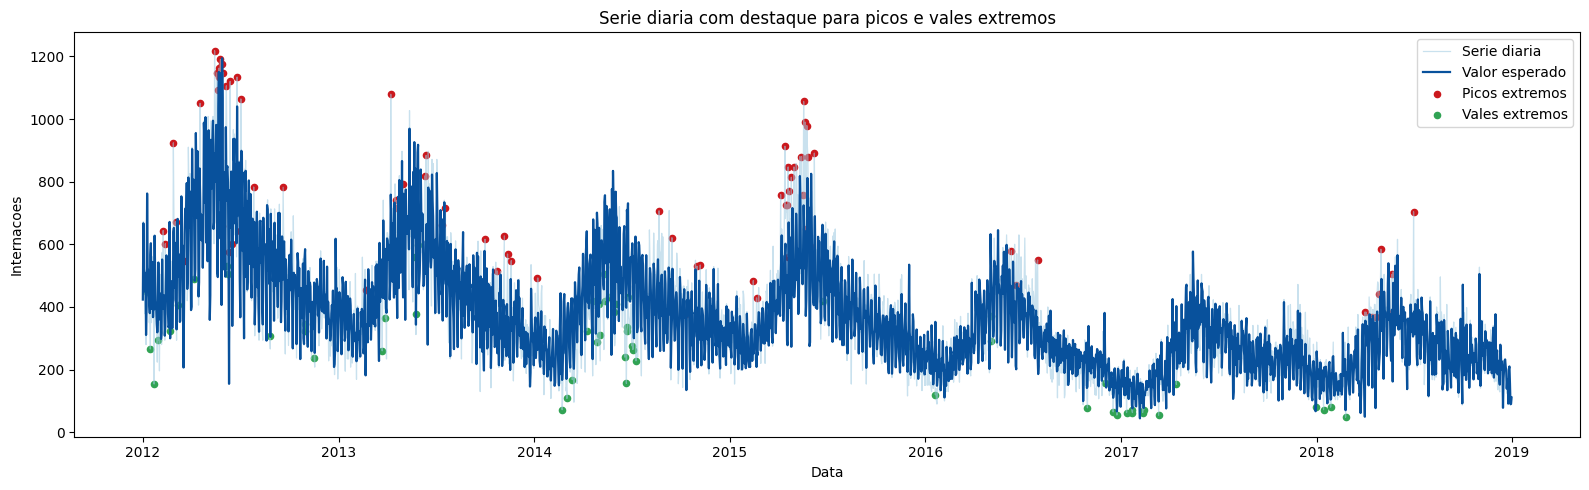

In [5]:
colunas_resumo_extremos = ["num_internacoes", "valor_esperado", "desvio_ajustado", "z_robusto"]

top_picos = (
    df_extremos.nlargest(10, "num_internacoes")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)
top_vales = (
    df_extremos.nsmallest(10, "num_internacoes")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)
top_anomalias_positivas = (
    df_extremos.nlargest(10, "desvio_ajustado")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)
top_anomalias_negativas = (
    df_extremos.nsmallest(10, "desvio_ajustado")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)

display(top_picos.round(2))
display(top_vales.round(2))
display(top_anomalias_positivas.round(2))
display(top_anomalias_negativas.round(2))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_extremos.index, df_extremos["num_internacoes"], color="#9ecae1", linewidth=0.9, alpha=0.55, label="Serie diaria")
ax.plot(df_extremos.index, df_extremos["valor_esperado"], color="#08519c", linewidth=1.6, label="Valor esperado")
ax.scatter(
    df_extremos.index[df_extremos["pico_extremo"]],
    df_extremos.loc[df_extremos["pico_extremo"], "num_internacoes"],
    color="#cb181d",
    s=20,
    label="Picos extremos",
)
ax.scatter(
    df_extremos.index[df_extremos["vale_extremo"]],
    df_extremos.loc[df_extremos["vale_extremo"], "num_internacoes"],
    color="#31a354",
    s=20,
    label="Vales extremos",
)
ax.set_title("Serie diaria com destaque para picos e vales extremos")
ax.set_xlabel("Data")
ax.set_ylabel("Internacoes")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Frequencia e distribuicao dos extremos

Agora quantificamos quantos extremos existem ao longo de toda a serie e em quais anos e meses eles se concentram. Isso ajuda a responder se os eventos raros estao espalhados ao acaso ou se aparecem em certos regimes e janelas sazonais.

,tipo,quantidade,percentual_dias
0,Picos extremos,79,3.09
1,Vales extremos,61,2.39
2,Extremos totais,140,5.48


,ano,dias,picos_extremos,vales_extremos,total_extremos,taxa_extremos_pct
0,2012,366,26,13,39,10.66
2,2014,365,6,22,28,7.67
1,2013,365,16,6,22,6.03
3,2015,365,20,2,22,6.03
6,2018,365,8,3,11,3.01
4,2016,366,3,7,10,2.73
5,2017,365,0,8,8,2.19


,mes_nome,picos_extremos,vales_extremos,total_extremos
0,Jan,1,10,11
1,Fev,6,5,11
2,Mar,2,6,8
3,Abr,18,5,23
4,Mai,23,13,36
5,Jun,10,9,19
6,Jul,8,3,11
7,Ago,1,1,2
8,Set,2,0,2
9,Out,3,3,6


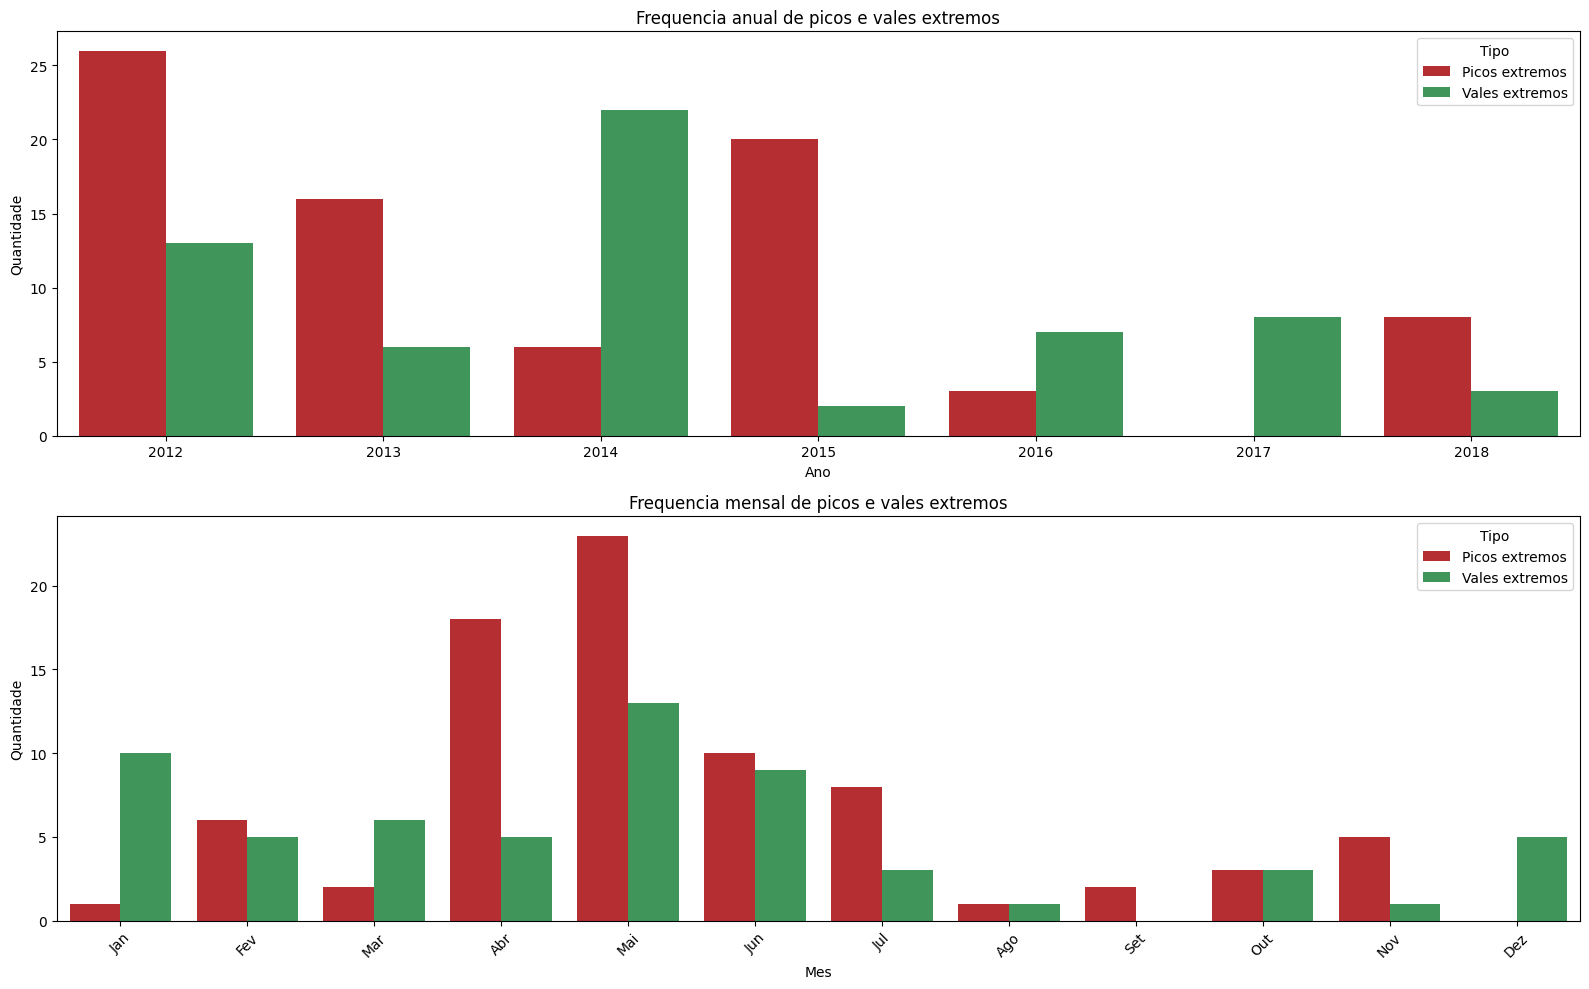

In [6]:
resumo_frequencia_extremos = pd.DataFrame(
    {
        "tipo": ["Picos extremos", "Vales extremos", "Extremos totais"],
        "quantidade": [
            int(df_extremos["pico_extremo"].sum()),
            int(df_extremos["vale_extremo"].sum()),
            int(df_extremos["extremo"].sum()),
        ],
    }
)
resumo_frequencia_extremos["percentual_dias"] = 100 * resumo_frequencia_extremos["quantidade"] / len(df_extremos)

frequencia_por_ano = (
    df_extremos.groupby("ano")
    .agg(
        dias=("num_internacoes", "size"),
        picos_extremos=("pico_extremo", "sum"),
        vales_extremos=("vale_extremo", "sum"),
        total_extremos=("extremo", "sum"),
    )
    .reset_index()
)
frequencia_por_ano["taxa_extremos_pct"] = 100 * frequencia_por_ano["total_extremos"] / frequencia_por_ano["dias"]

frequencia_por_mes = (
    df_extremos.groupby(["mes", "mes_nome"], observed=True)
    .agg(
        picos_extremos=("pico_extremo", "sum"),
        vales_extremos=("vale_extremo", "sum"),
        total_extremos=("extremo", "sum"),
    )
    .reset_index()
    .sort_values("mes")
)

display(resumo_frequencia_extremos.round(2))
display(frequencia_por_ano.sort_values("total_extremos", ascending=False).head(10).round(2))
display(frequencia_por_mes[["mes_nome", "picos_extremos", "vales_extremos", "total_extremos"]].round(2))

freq_ano_long = frequencia_por_ano.melt(
    id_vars="ano",
    value_vars=["picos_extremos", "vales_extremos"],
    var_name="tipo",
    value_name="quantidade",
)
freq_ano_long["tipo"] = freq_ano_long["tipo"].map({"picos_extremos": "Picos extremos", "vales_extremos": "Vales extremos"})

freq_mes_long = frequencia_por_mes.melt(
    id_vars=["mes", "mes_nome"],
    value_vars=["picos_extremos", "vales_extremos"],
    var_name="tipo",
    value_name="quantidade",
)
freq_mes_long["tipo"] = freq_mes_long["tipo"].map({"picos_extremos": "Picos extremos", "vales_extremos": "Vales extremos"})

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

sns.barplot(data=freq_ano_long, x="ano", y="quantidade", hue="tipo", palette=["#cb181d", "#31a354"], ax=axes[0])
axes[0].set_title("Frequencia anual de picos e vales extremos")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Quantidade")
axes[0].legend(title="Tipo", loc="upper right")

sns.barplot(data=freq_mes_long, x="mes_nome", y="quantidade", hue="tipo", palette=["#cb181d", "#31a354"], ax=axes[1])
axes[1].set_title("Frequencia mensal de picos e vales extremos")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Quantidade")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Tipo", loc="upper right")

plt.tight_layout()
plt.show()

### Inspecao de janelas em torno dos eventos raros

A tabela de extremos mostra *onde* olhar. Agora montamos janelas de contexto para ver *como* cada evento se comporta no entorno. Em saude, isso ajuda a distinguir um pico isolado, um vale administrativo ou um trecho que faz parte de uma onda mais longa.

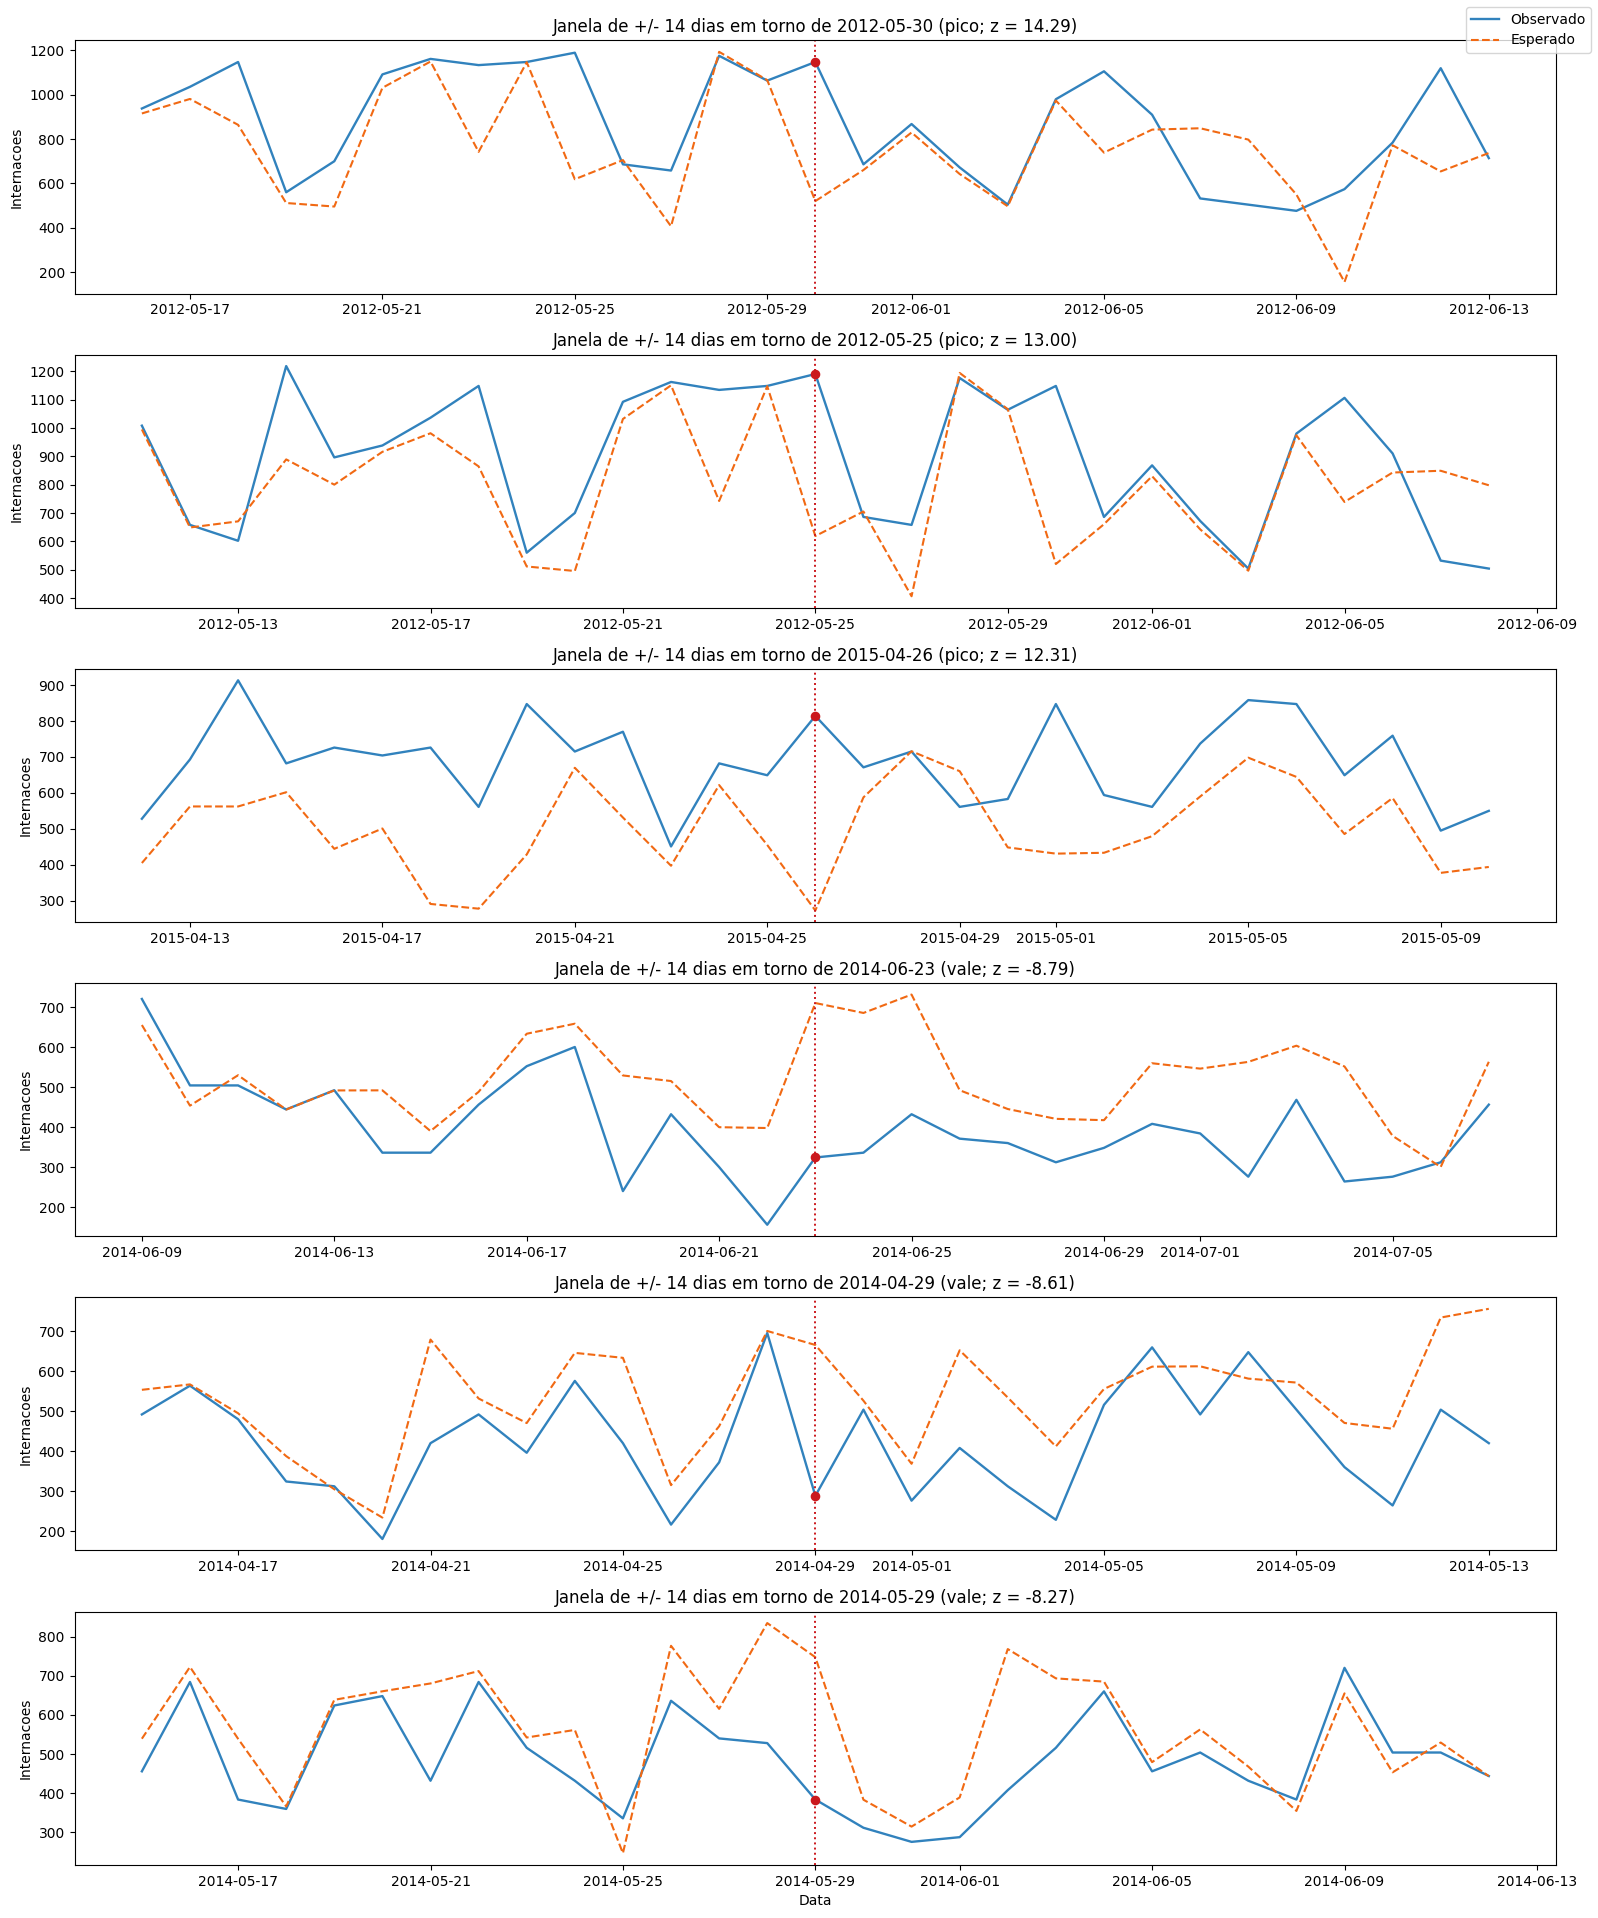

,data_evento,tipo_evento,valor_evento,valor_esperado,desvio_ajustado,z_robusto,media_janela,min_janela,max_janela
0,2012-05-30,Pico,1148,520.07,627.93,14.29,871.38,476,1190
1,2012-05-25,Pico,1190,618.71,571.29,13.00,896.00,504,1218
2,2015-04-26,Pico,814,272.89,541.11,12.31,685.79,451,913
3,2014-06-23,Vale,324,709.82,-385.82,-8.79,393.07,156,720
4,2014-04-29,Vale,288,666.01,-378.01,-8.61,424.97,180,696
5,2014-05-29,Vale,384,747.16,-363.16,-8.27,484.55,276,720


In [7]:
def resumir_janelas_evento(df_base, datas_evento, dias_janela=14):
    resumos = []
    for data_evento in datas_evento:
        janela = df_base.loc[
            data_evento - pd.Timedelta(days=dias_janela): data_evento + pd.Timedelta(days=dias_janela)
        ].copy()
        if janela.empty:
            continue
        resumos.append(
            {
                "data_evento": data_evento,
                "tipo_evento": "Pico" if df_base.loc[data_evento, "desvio_ajustado"] >= 0 else "Vale",
                "valor_evento": df_base.loc[data_evento, "num_internacoes"],
                "valor_esperado": df_base.loc[data_evento, "valor_esperado"],
                "desvio_ajustado": df_base.loc[data_evento, "desvio_ajustado"],
                "z_robusto": df_base.loc[data_evento, "z_robusto"],
                "media_janela": janela["num_internacoes"].mean(),
                "min_janela": janela["num_internacoes"].min(),
                "max_janela": janela["num_internacoes"].max(),
            }
        )
    return pd.DataFrame(resumos)

# Selecionamos alguns eventos para inspecao detalhada combinando anomalias positivas e negativas.
datas_inspecao = list(
    dict.fromkeys(
        list(df_extremos.nlargest(3, "desvio_ajustado").index)
        + list(df_extremos.nsmallest(3, "desvio_ajustado").index)
    )
)

dias_janela = 14
fig, axes = plt.subplots(len(datas_inspecao), 1, figsize=(16, 3.2 * len(datas_inspecao)), sharex=False)
if len(datas_inspecao) == 1:
    axes = [axes]

for ax, data_evento in zip(axes, datas_inspecao):
    janela = df_extremos.loc[
        data_evento - pd.Timedelta(days=dias_janela): data_evento + pd.Timedelta(days=dias_janela)
    ].copy()
    ax.plot(janela.index, janela["num_internacoes"], color="#3182bd", linewidth=1.7, label="Observado")
    ax.plot(janela.index, janela["valor_esperado"], color="#f16913", linestyle="--", linewidth=1.5, label="Esperado")
    ax.axvline(data_evento, color="#cb181d", linestyle=":", linewidth=1.4)
    ax.scatter([data_evento], [df_extremos.loc[data_evento, "num_internacoes"]], color="#cb181d", s=35, zorder=3)
    tipo_evento = "pico" if df_extremos.loc[data_evento, "desvio_ajustado"] >= 0 else "vale"
    ax.set_title(
        f"Janela de +/- {dias_janela} dias em torno de {data_evento.date()} ({tipo_evento}; z = {df_extremos.loc[data_evento, 'z_robusto']:.2f})"
    )
    ax.set_ylabel("Internacoes")

axes[-1].set_xlabel("Data")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

display(resumir_janelas_evento(df_extremos, datas_inspecao, dias_janela=dias_janela).round(2))

### Resumo interpretativo dos resultados

A análise atualizada mostrou que os extremos da série seguem **assimétricos** e **não aleatórios no tempo**. Nesta execução, foram identificados **140 dias extremos (5,48% da série)**, com predomínio de **picos extremos (79 dias; 3,09%)** sobre **vales extremos (61 dias; 2,39%)**. Isso reforça que os eventos raros aparecem mais como **ondas de alta** do que como quedas abruptas persistentes, embora os vales também tenham peso relevante.

Nos **maiores picos brutos**, os valores mais altos ficaram novamente concentrados em **maio-junho de 2012**, com destaque para **2012-05-14 (1218)**, **2012-05-25 (1190)** e **2012-05-28 (1176)**. Pela leitura de **anomalias ajustadas**, o maior desvio positivo foi **2012-05-30**, com **1148 internações** frente a **520,1 esperadas**, resultando em **desvio ajustado de +627,9** e `z_robusto = 14,29`. Também se destacaram **2012-05-25 (+571,3)** e **2015-04-26 (+541,1)**. Isso confirma que o ajuste por tendência + sazonalidade é essencial para separar valor absoluto alto de anomalia real.

Nos **vales**, os menores valores brutos apareceram em datas recentes e de verão, como **2018-02-24 (48)** e **2017-03-12 (54)**, mas com desvios ajustados em geral moderados. Já os vales ajustados mais fortes ficaram concentrados em **2014**, com destaque para **2014-06-23 (-385,8)**, **2014-04-29 (-378,0)** e **2014-05-29 (-363,2)**. Esse contraste sugere que parte dos vales mais relevantes ocorre em meses estruturalmente altos, podendo refletir calendário, mudança operacional ou sub-registro local.

A distribuição temporal reforça esse diagnóstico. O ano de **2012** concentrou **39 extremos** (taxa de **10,66%** dos dias), seguido por **2014 (28; 7,67%)**, **2013 (22; 6,03%)** e **2015 (22; 6,03%)**. Em **2017**, não houve picos extremos detectados (apenas vales). No calendário anual, a concentração foi maior em **abril, maio e junho**, com destaque para **maio (36 extremos: 23 picos e 13 vales)**; em **janeiro** e **dezembro** prevaleceram vales.

As **janelas locais** ajudam a interpretar o contexto dos eventos. Os principais picos ocorreram em janelas já elevadas, com médias de aproximadamente **685,8 a 896,0 internações**, indicando **ondas prolongadas**. Em contraste, os vales ajustados mais fortes ocorreram em janelas de **393,1 a 484,6**, funcionando como quedas localizadas dentro de períodos ainda relevantes. Isso reforça que extremo não deve ser tratado automaticamente como ruído sem contexto.

**Possíveis análises e consequências**
- Os grandes picos de **2012** e **2015** devem ser tratados como eventos substantivos e cruzados com clima, poluição, surtos e fatores assistenciais.
- A detecção ajustada por tendência + sazonalidade é mais informativa do que olhar apenas os valores brutos.
- Para modelagem, vale usar abordagens robustas a outliers e incluir `dummies` de evento/regime em vez de excluir extremos automaticamente.
- Os vales ajustados fortes de **2014** merecem verificação de qualidade de dado e de contexto operacional.
- A concentração de extremos por ano e por mês reforça a hipótese de **não estacionariedade** e de **comportamento por ondas/regimes**.